In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
from crawler_analysis_final import *
from deep_translator import GoogleTranslator

In [3]:
df = read_data()

In [4]:
df_new = df.drop("photos", axis=1)
df_new.nunique()

link                     2251
city                      272
street                   1590
price                     682
type                        3
rooms                       5
surface                   216
furnished                   2
description              2232
description_eng          2230
near_school                 2
near_hospital               2
near_public_transport       2
near_services               2
dtype: int64

            city_count
city                  
Amsterdam           89
Arnhem              55
Breda               85
Den Haag           182
Eindhoven          125
Enschede            57
Groningen          127
Haarlem             25
Heerlen             24
Leeuwarden          44
Leiden              47
Maastricht         150
Rotterdam          279
Tilburg             80
Utrecht            119
Zwolle              54


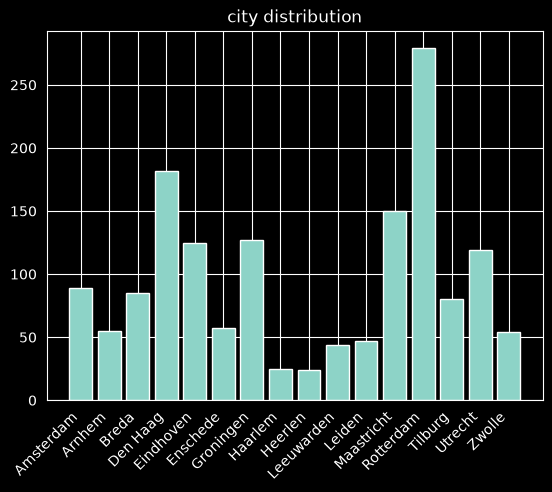

In [5]:
show_city_distribution(df)

### Rozkład ofert w miejscowościach

In [6]:
df.dtypes

link                         str
city                         str
street                       str
price                    float64
type                         str
rooms                    float64
surface                  float64
furnished                    str
description                  str
description_eng              str
near_school                int64
near_hospital              int64
near_public_transport      int64
near_services              int64
photos                    object
dtype: object

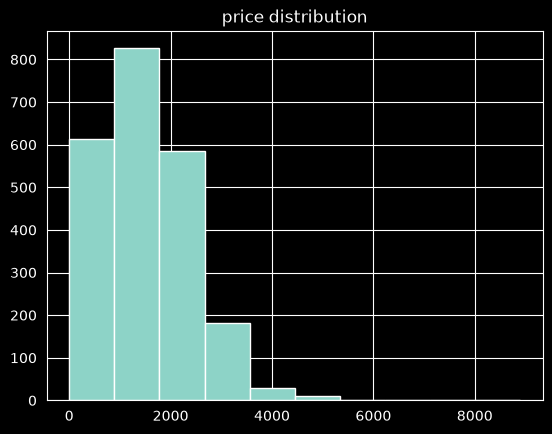

In [7]:
show_distribution(df, "price", 10)


### Rozkład cen za wynajem ofert


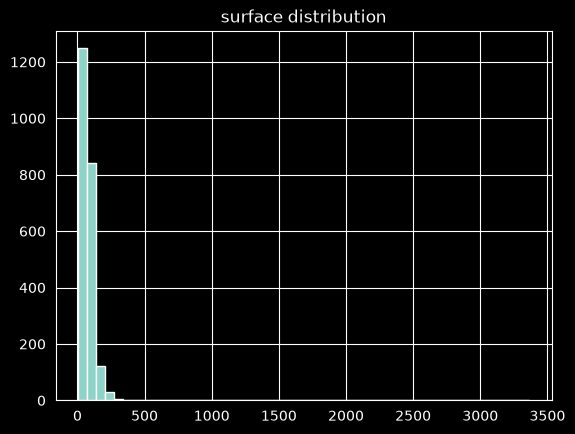

In [8]:
show_distribution(df, "surface", 50)


Rozkład powierzchni lokum dostępnych na stronie

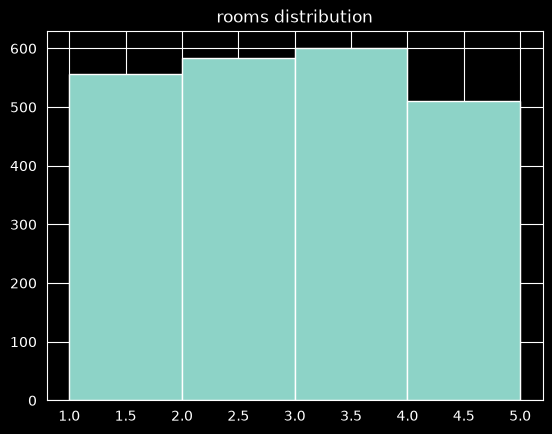

In [9]:
show_distribution(df, "rooms", 4)


Rozkład liczby pokoi w ofertach

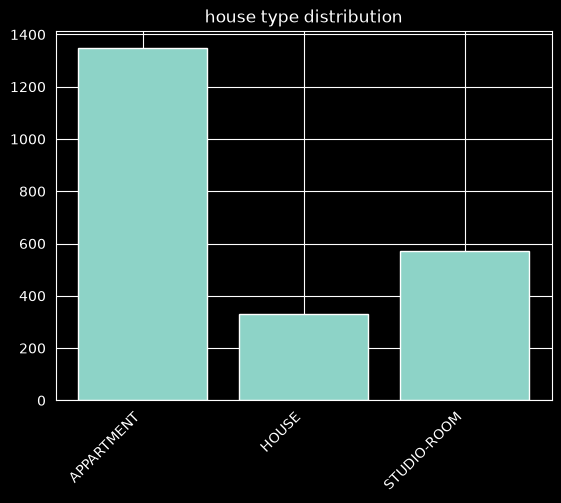

In [10]:
show_house_type_distribution(df)


Liczba lokum dostępnych w danym rodzaju

/home/julia/PycharmProjects/PythonProject/crawler_analysis.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["furnished", "unfurnished"], rotation=45)


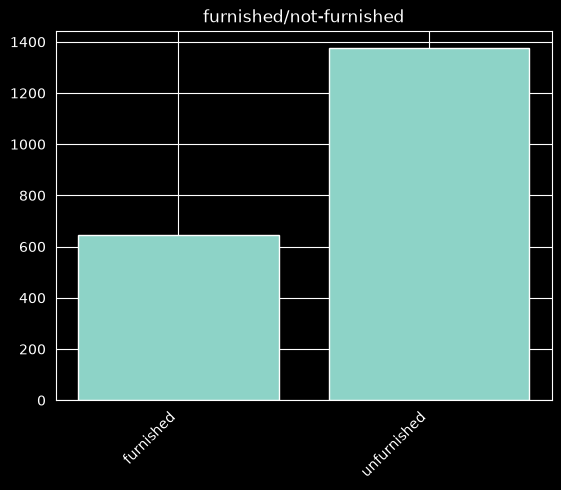

In [11]:
show_if_furnished(df)

Liczba ofert lokum umeblowanych i nieumeblowanych

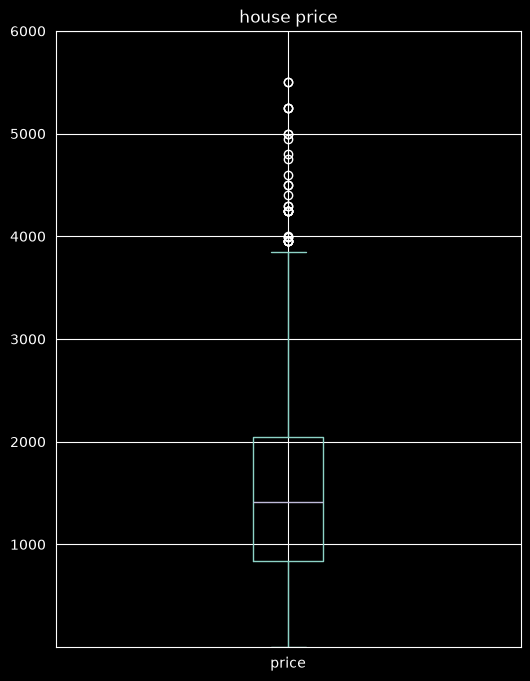

In [12]:
box_price = df["price"].plot(kind="box", title="house price", figsize=(6,8), layout=(4, 4), ylim=(1, 6000))
plt.show()

Wykres skrzynkowy ofert o danej cenie

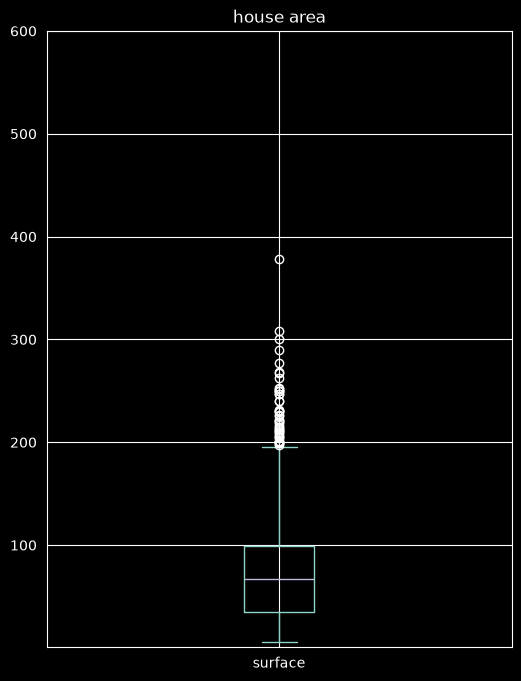

In [13]:
box_surface = df["surface"].plot(kind="box", title="house area", figsize=(6,8), layout=(4, 4), ylim=(1, 600))
plt.show()

Wykres szkrzynkowy ofert o danej powierzchni

In [14]:
df.describe().round(4)

,price,rooms,surface,near_school,near_hospital,near_public_transport,near_services
count,2251.0000,2251.0000,2251.0000,2251.0000,2251.0000,2251.0000,2251.0000
mean,1542.2661,2.5686,74.6499,0.1755,0.0195,0.6144,0.3305
std,881.0897,1.2568,89.6504,0.3805,0.1385,0.4868,0.4705
min,1.0000,1.0000,6.0000,0.0000,0.0000,0.0000,0.0000
25%,834.0000,2.0000,35.0000,0.0000,0.0000,0.0000,0.0000
50%,1413.0000,2.0000,67.0000,0.0000,0.0000,1.0000,0.0000
75%,2050.0000,3.0000,99.0000,0.0000,0.0000,1.0000,1.0000
max,8895.0000,5.0000,3364.0000,1.0000,1.0000,1.0000,1.0000


Podstawowe statystyki

In [15]:
df[["price", "rooms", "surface", "near_school", "near_hospital", "near_public_transport", "near_services"]].corr()

,price,rooms,surface,near_school,near_hospital,near_public_transport,near_services
price,1.000000,0.662882,0.371466,0.120826,0.021290,0.101249,0.171298
rooms,0.662882,1.000000,0.467822,0.181607,0.045918,0.015672,0.103669
surface,0.371466,0.467822,1.000000,0.081482,0.027833,-0.006536,0.062508
near_school,0.120826,0.181607,0.081482,1.000000,0.061409,0.115930,-0.001379
near_hospital,0.021290,0.045918,0.027833,0.061409,1.000000,0.026152,0.084981
near_public_transport,0.101249,0.015672,-0.006536,0.115930,0.026152,1.000000,0.054116
near_services,0.171298,0.103669,0.062508,-0.001379,0.084981,0.054116,1.000000


Macierz korelacji

In [16]:
df.isnull().sum()

link                       0
city                       0
street                     0
price                      0
type                       0
rooms                      0
surface                    0
furnished                230
description                0
description_eng            0
near_school                0
near_hospital              0
near_public_transport      0
near_services              0
photos                    34
dtype: int64

Braki danych

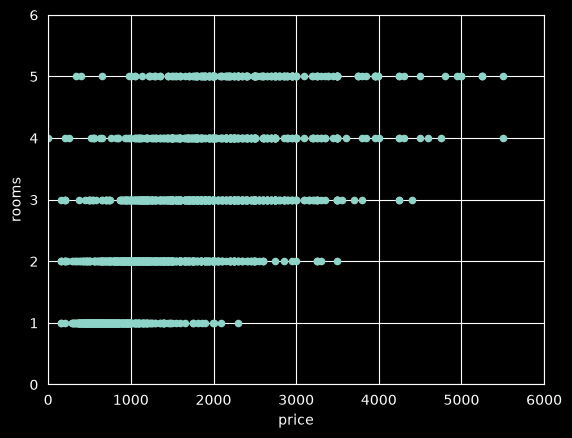

In [17]:
df.plot.scatter(x="price", y="rooms", xlim = (0,6000), ylim = (0,6))
plt.show()

Zależność ceny od liczby pokoi